In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
from matplotlib.ticker import LogLocator

# === Setup ===
sns.set(style="white")
unit_label = " Ratio"

# === Load prediction results ===
pred_df = pd.read_csv("/130TB_RAID0/hangkai/Antarctica_Mapping_Data/Continental_results_permutation/all_test_predictions.csv")

# === Load R2 and RMSE from txt ===
with open("/130TB_RAID0/hangkai/Antarctica_Mapping_Data/Continental_results_permutation/cv_scores.txt", "r") as f:
    lines = f.readlines()
    r2_val = float(lines[0].split(":")[1].split("+/-")[0].strip())
    rmse_val = float(lines[1].split(":")[1].split("+/-")[0].strip())

# === Use observed and predicted values ===
x = pred_df["Observed"]
y = pred_df["Predicted"]

/tmp/ipykernel_346703/1051965137.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])  # leave room for colorbar


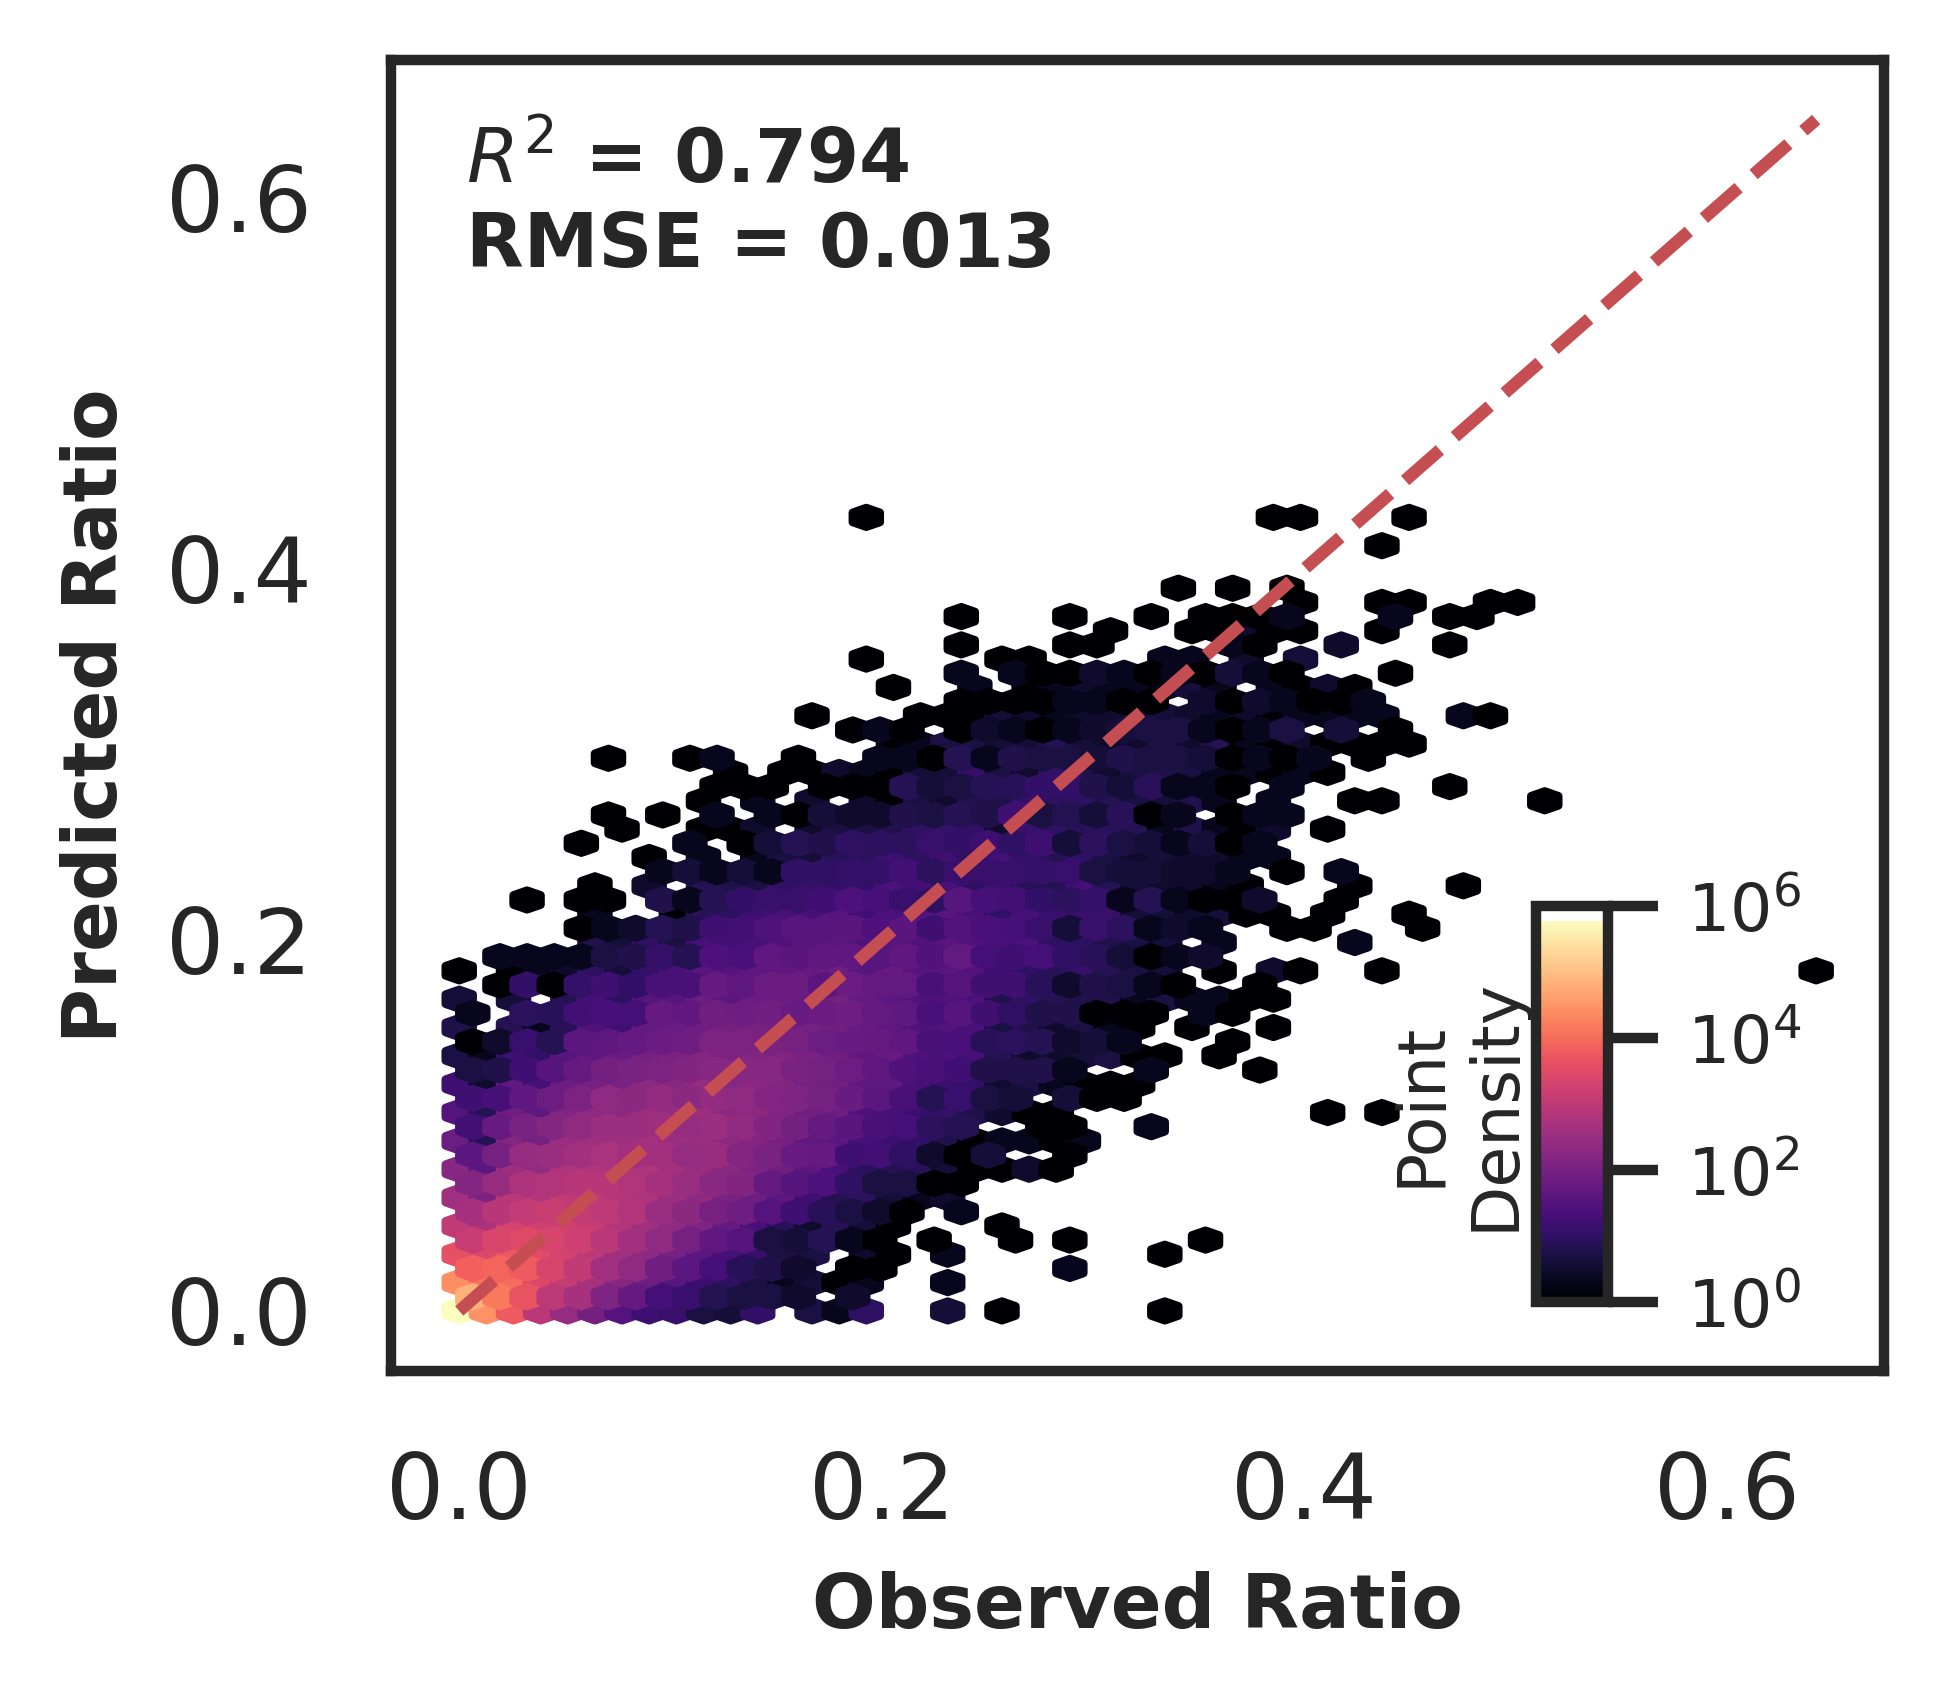

✅ Figure saved to: /130TB_RAID0/hangkai/Antarctica_Mapping_Data/SM_RF_hexbin_prediction_green_area_fraction_continental.png


In [20]:
# === Create single-panel plot ===
fig, ax = plt.subplots(figsize=(4, 3), dpi=600)

# === Hexbin plot ===
hb = ax.hexbin(x, y, gridsize=50, cmap='magma', bins='log')
ax.plot([x.min(), x.max()], [x.min(), x.max()], 'r--', linewidth=1.5)

# === Labels ===
ax.set_xlabel(f"Observed{unit_label}", fontsize=9, fontweight='bold')
ax.set_ylabel(f"Predicted{unit_label}", fontsize=9, fontweight='bold')

# === R² and RMSE annotation ===
ax.text(0.05, 0.95,
        f"$R^2$ = {r2_val:.3f}\nRMSE = {rmse_val:.3f}",
        transform=ax.transAxes, verticalalignment='top',
        fontsize=9, fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.6))

ax.grid(False)

# === Colorbar ===
cax = fig.add_axes([0.66, 0.25, 0.03, 0.22])  # adjust as needed
cb = fig.colorbar(hb, cax=cax)
cb.ax.yaxis.set_label_position("left")
cb.ax.yaxis.tick_left()
cb.ax.set_ylabel("Point\nDensity", fontsize=8, rotation=90, labelpad=1)
cb.locator = LogLocator(base=10.0, subs='auto', numticks=4)
cb.ax.yaxis.set_ticks_position('right')
cb.update_ticks()
cb.set_ticks([1, 100, 10000, 1000000])
cb.set_ticklabels(["$10^0$", "$10^2$", "$10^4$", "$10^6$"])
cb.ax.tick_params(labelsize=8, direction='out')

# === Layout and Save ===
plt.tight_layout(rect=[0, 0, 0.85, 1])  # leave room for colorbar
output_path = "/130TB_RAID0/hangkai/Antarctica_Mapping_Data/SM_RF_hexbin_prediction_green_area_fraction_continental.png"
plt.savefig(output_path, dpi=1000, bbox_inches='tight')
plt.show()
print(f"✅ Figure saved to: {output_path}")

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
from matplotlib.ticker import LogLocator

# === Setup ===
sns.set(style="white")
regions = ["West", "East", "Peninsula"]
unit = " Ratio"
pretty_names = {"AreaRatio": ""}  # only one type used
var_type = "AreaRatio"

# === File paths ===
base_path = "/130TB_RAID0/hangkai/Antarctica_Mapping_Data/Regional_results_permutation"
pred_files = {region: os.path.join(base_path, region, "all_test_predictions.csv") for region in regions}
score_files = {region: os.path.join(base_path, region, "cv_scores.txt") for region in regions}

# === Load predictions and scores ===
data_dict = {}
for region in regions:
    pred_df = pd.read_csv(pred_files[region])
    with open(score_files[region], "r") as f:
        lines = f.readlines()
        r2_val = float(lines[0].split(":")[1].split("+/-")[0].strip())
        rmse_val = float(lines[1].split(":")[1].split("+/-")[0].strip())
    data_dict[region] = {
        "df": pred_df,
        "r2": r2_val,
        "rmse": rmse_val
    }

/tmp/ipykernel_346703/2255123072.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


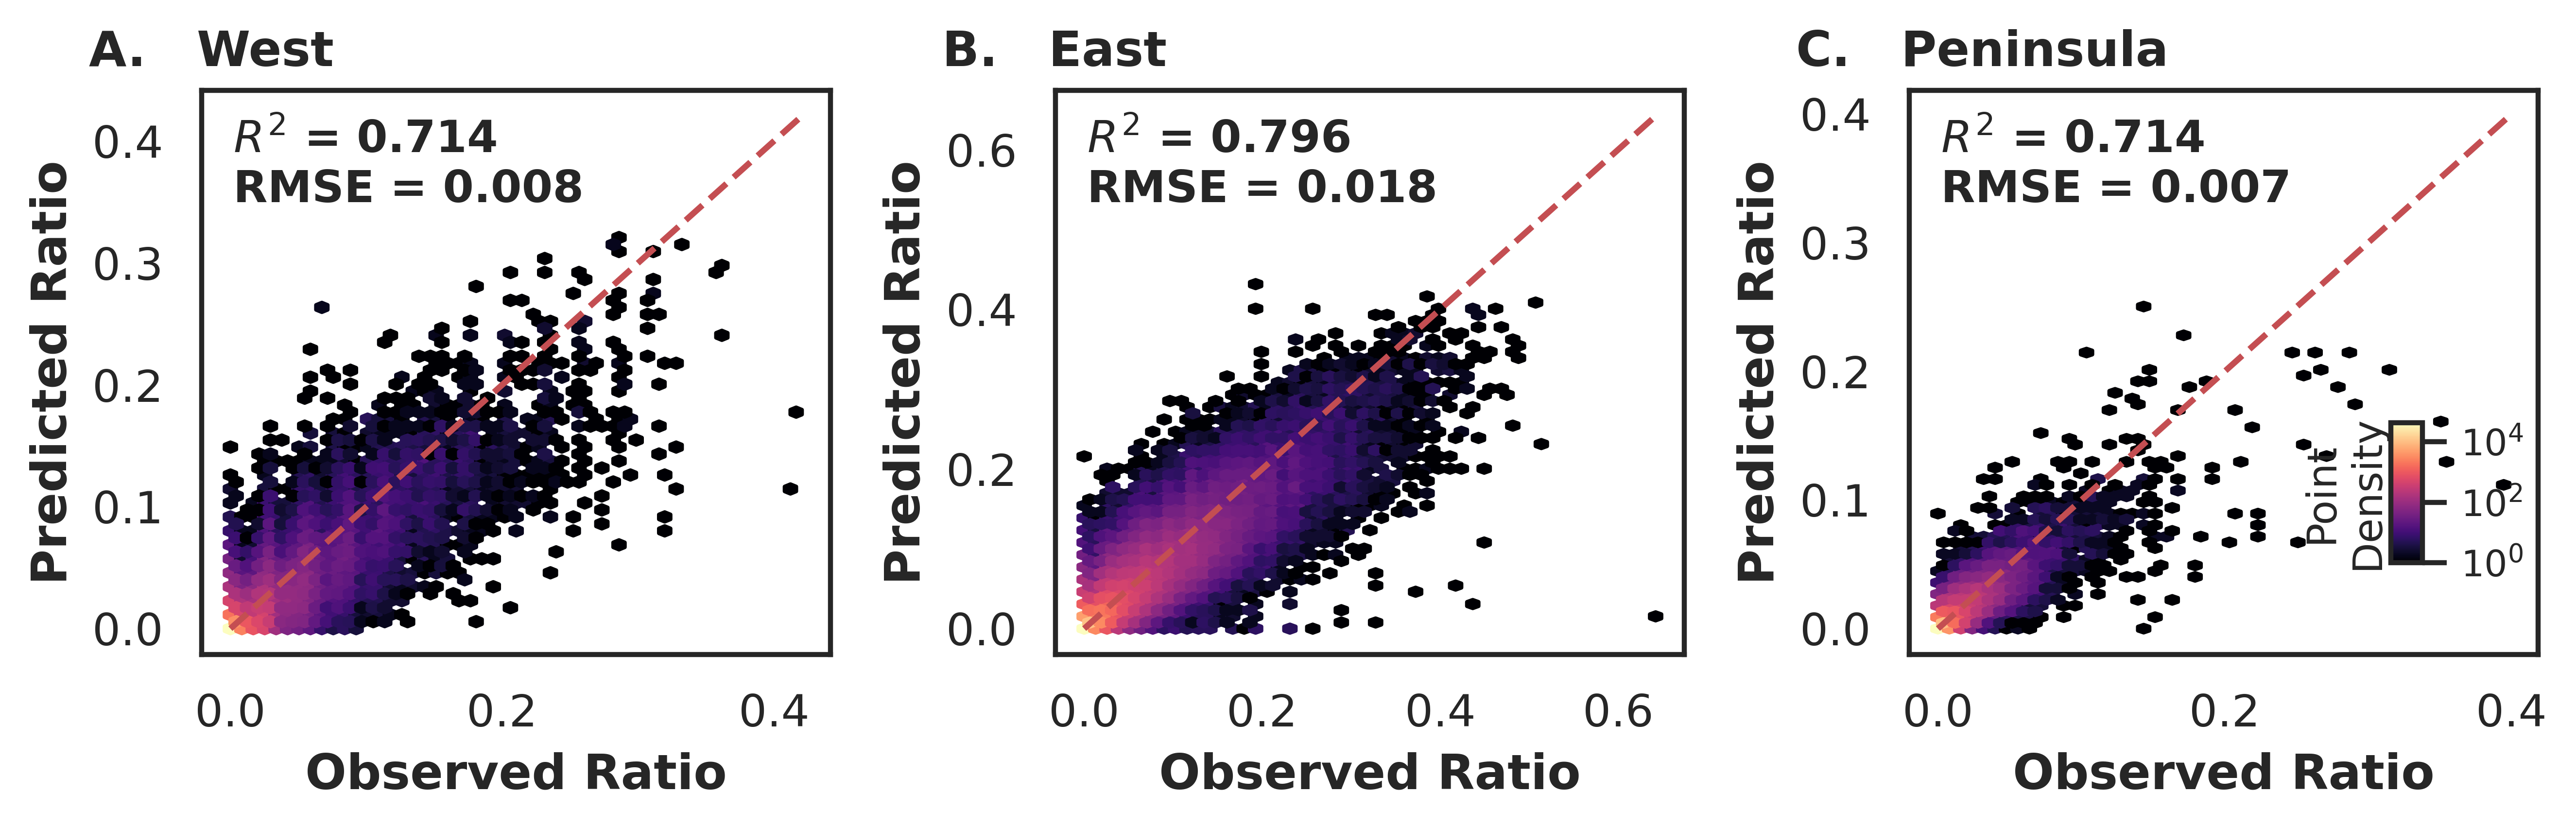

✅ Figure saved to: /130TB_RAID0/hangkai/Antarctica_Mapping_Data/SM_RF_hexbin_prediction_green_area_fraction_by_region.png


In [16]:
# === Create subplots: 1 row x 3 columns ===
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(9, 3), dpi=600)
axes = axes.flatten()

plot_idx = 0
hexbin_for_cb = None  # store the last hexbin for shared colorbar

for region in regions:
    ax = axes[plot_idx]
    df = data_dict[region]["df"]
    x = df["Observed"]
    y = df["Predicted"]

    # === Hexbin plot ===
    hb = ax.hexbin(x, y, gridsize=50, cmap='magma', bins='log')
    hexbin_for_cb = hb
    ax.plot([x.min(), x.max()], [x.min(), x.max()], 'r--', linewidth=1.5)

    # === Labels and title ===
    pretty_label = pretty_names[var_type]
    ax.set_xlabel(f"Observed{unit}", fontsize=12, fontweight='bold')
    ax.set_ylabel(f"Predicted{unit}", fontsize=12, fontweight='bold')
    ax.set_title(f"{chr(65 + plot_idx)}.   {region} {pretty_label}",
                 fontsize=12, fontweight='bold', loc='left', x=-0.18)

    # === R² and RMSE annotation ===
    r2_val = data_dict[region]["r2"]
    rmse_val = data_dict[region]["rmse"]
    ax.text(0.05, 0.95, f"$R^2$ = {r2_val:.3f}\nRMSE = {rmse_val:.3f}",
            transform=ax.transAxes, verticalalignment='top',
            fontsize=11, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.6))
    ax.grid(False)
    plot_idx += 1

# === Shared colorbar: bottom-right corner of center subplot ===
cax = fig.add_axes([0.92, 0.33, 0.012, 0.16])  # adjust as needed
cb = fig.colorbar(hexbin_for_cb, cax=cax)
cb.ax.yaxis.set_label_position("left")
cb.ax.set_ylabel("Point\nDensity", fontsize=10, rotation=90, labelpad=1)
cb.ax.yaxis.set_ticks_position('right')
cb.ax.yaxis.set_tick_params(which='both', direction='out')
cb.update_ticks()
cb.set_ticks([1, 100, 10000])
cb.set_ticklabels(["$10^0$", "$10^2$", "$10^4$"])
cb.ax.tick_params(labelsize=9)

# === Final layout and save ===
plt.tight_layout()
output_path = "/130TB_RAID0/hangkai/Antarctica_Mapping_Data/SM_RF_hexbin_prediction_green_area_fraction_by_region.png"
plt.savefig(output_path, dpi=1000, bbox_inches='tight')
plt.show()
print(f"✅ Figure saved to: {output_path}")